# FashionMNIST Model Training, Evaluation & Export
---
**Assignment Phase 1**: Train CNN and DNN models on FashionMNIST, compare performance, and export the best model for deployment.

| Model | Params | Type |
|-------|--------|------|
| CNN   | ~62k   | 2-Conv + 3-FC |
| DNN   | ~1.18M | 4-Layer FC (784→512→512→512→10) |

In [27]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    confusion_matrix, classification_report
)
import seaborn as sns
from pathlib import Path
import json

# Import project modules
from data_loader import (
    train_image_data, test_image_data,
    get_train_data_loaders, get_test_data_loaders, get_data_classes,
    get_device
)
from cnn import CNN, train_cnn
from dnn import DNN

# Setup
device = get_device() 
CLASS_NAMES = get_data_classes()
BATCH_SIZE = 64
print(f"Device: {device}")
print(f"Classes: {CLASS_NAMES}")

Device: mps
Classes: ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


In [28]:
# ---- Data Loaders ----
train_loader = get_train_data_loaders(batch_size=BATCH_SIZE)
test_loader = get_test_data_loaders(batch_size=BATCH_SIZE)

print(f"Train batches: {len(train_loader)} (x{BATCH_SIZE})")
print(f"Test batches:  {len(test_loader)} (x{BATCH_SIZE})")

Train batches: 938 (x64)
Test batches:  157 (x64)


In [29]:
# ---- DNN Training Function ----
# DNN.py provides the class; define a reusable training loop

def train_dnn(model, train_loader, test_loader, epochs=15, lr=0.01, momentum=0.9, device='cpu'):
    """Train DNN and return history dict matching CNN's train_cnn format."""
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=momentum)
    
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    
    print(f"{'Epoch':<8} {'Train Loss':<12} {'Train Acc':<12} {'Val Loss':<12} {'Val Acc':<12}")
    print("-" * 56)
    
    for epoch in range(epochs):
        # Train
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
        
        train_loss = running_loss / total
        train_acc = correct / total
        
        # Evaluate
        model.eval()
        running_loss, correct, total = 0.0, 0, 0
        with torch.no_grad():
            for inputs, labels in test_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                running_loss += loss.item() * inputs.size(0)
                _, preds = torch.max(outputs, 1)
                correct += (preds == labels).sum().item()
                total += labels.size(0)
        
        val_loss = running_loss / total
        val_acc = correct / total
        
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        
        print(f"{epoch+1:<8} {train_loss:<12.4f} {train_acc:<12.4f} {val_loss:<12.4f} {val_acc:<12.4f}")
    
    return history

In [30]:
# ---- Count Parameters ----
cnn_model = CNN()
dnn_model = DNN()

cnn_params = sum(p.numel() for p in cnn_model.parameters())
dnn_params = sum(p.numel() for p in dnn_model.parameters())

print(f"{'Model':<10} {'Parameters':>12} {'Trainable':>12}")
print("-" * 36)
print(f"{'CNN':<10} {cnn_params:>12,} {cnn_params:>12,}")
print(f"{'DNN':<10} {dnn_params:>12,} {dnn_params:>12,}")
print(f"\nDNN has {dnn_params/cnn_params:.1f}x more parameters than CNN")

Model        Parameters    Trainable
------------------------------------
CNN              44,426       44,426
DNN             932,362      932,362

DNN has 21.0x more parameters than CNN


In [31]:
# ===================================================================
#  Train CNN
# ===================================================================
print("=" * 60)
print("Training CNN on FashionMNIST")
print("=" * 60)

cnn_model = CNN().to(device)
cnn_history = train_cnn(
    cnn_model, train_loader, test_loader,
    epochs=10, lr=0.01, momentum=0.9, device=str(device)
)

Training CNN on FashionMNIST
Epoch    Train Loss   Train Acc    Val Loss     Val Acc     
--------------------------------------------------------
1        0.9432       0.6417       0.5491       0.7927      
2        0.5420       0.7953       0.5379       0.7908      
3        0.4740       0.8226       0.4419       0.8289      
4        0.4373       0.8365       0.4206       0.8420      
5        0.4101       0.8466       0.3875       0.8561      
6        0.3918       0.8544       0.3927       0.8498      
7        0.3787       0.8598       0.3923       0.8510      
8        0.3658       0.8611       0.3841       0.8583      
9        0.3584       0.8661       0.3554       0.8676      
10       0.3503       0.8701       0.3738       0.8600      


In [32]:
# ===================================================================
#  Train DNN
# ===================================================================
print("=" * 60)
print("Training DNN on FashionMNIST")
print("=" * 60)

dnn_model = DNN().to(device)
dnn_history = train_dnn(
    dnn_model, train_loader, test_loader,
    epochs=15, lr=0.01, momentum=0.9, device=str(device)
)

Training DNN on FashionMNIST
Epoch    Train Loss   Train Acc    Val Loss     Val Acc     
--------------------------------------------------------
1        0.8419       0.6807       0.6249       0.7748      
2        0.5896       0.7769       0.5286       0.8075      
3        0.5296       0.8011       0.5203       0.8063      
4        0.4944       0.8140       0.4864       0.8140      
5        0.4690       0.8249       0.4476       0.8338      
6        0.4505       0.8323       0.4394       0.8350      
7        0.4358       0.8358       0.4246       0.8401      
8        0.4225       0.8410       0.4074       0.8484      
9        0.4136       0.8450       0.4003       0.8500      
10       0.4029       0.8490       0.3919       0.8556      
11       0.3951       0.8527       0.4156       0.8456      
12       0.3883       0.8532       0.3907       0.8534      
13       0.3807       0.8578       0.3809       0.8602      
14       0.3753       0.8591       0.3795       0.8604      

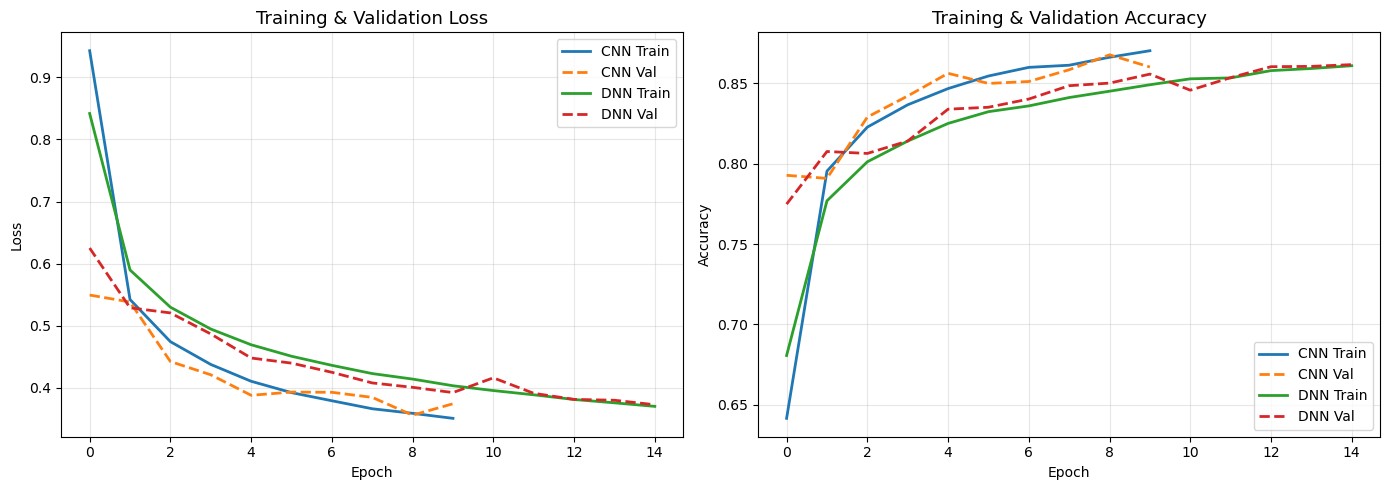

Saved: training_curves.png


In [33]:
# ===================================================================
#  Training Curves
# ===================================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
ax = axes[0]
ax.plot(cnn_history['train_loss'], label='CNN Train', linewidth=2)
ax.plot(cnn_history['val_loss'], label='CNN Val', linestyle='--', linewidth=2)
ax.plot(dnn_history['train_loss'], label='DNN Train', linewidth=2)
ax.plot(dnn_history['val_loss'], label='DNN Val', linestyle='--', linewidth=2)
ax.set_title('Training & Validation Loss', fontsize=13)
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.legend()
ax.grid(True, alpha=0.3)

# Accuracy
ax = axes[1]
ax.plot(cnn_history['train_acc'], label='CNN Train', linewidth=2)
ax.plot(cnn_history['val_acc'], label='CNN Val', linestyle='--', linewidth=2)
ax.plot(dnn_history['train_acc'], label='DNN Train', linewidth=2)
ax.plot(dnn_history['val_acc'], label='DNN Val', linestyle='--', linewidth=2)
ax.set_title('Training & Validation Accuracy', fontsize=13)
ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: training_curves.png')

In [34]:
# ===================================================================
#  Detailed Evaluation on Test Set
# ===================================================================
def get_predictions_and_labels(model, loader, device):
    """Collect all predictions and true labels from a DataLoader."""
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for inputs, labels in loader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            preds = outputs.argmax(dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.numpy())
    return np.array(all_preds), np.array(all_labels)

cnn_preds, y_true = get_predictions_and_labels(cnn_model, test_loader, device)
dnn_preds, _       = get_predictions_and_labels(dnn_model, test_loader, device)

print(f'Test set size: {len(y_true)}')

Test set size: 10000


In [35]:
# ---- Per-Class Accuracy & F1 ----
cnn_precision, cnn_recall, cnn_f1, _ = precision_recall_fscore_support(y_true, cnn_preds, average=None)
dnn_precision, dnn_recall, dnn_f1, _ = precision_recall_fscore_support(y_true, dnn_preds, average=None)

print(f"{'Class':<15} {'CNN Acc':>8} {'CNN F1':>8} {'DNN Acc':>8} {'DNN F1':>8}")
print("-" * 55)
for i, name in enumerate(CLASS_NAMES):
    cnn_acc_i = (cnn_preds[y_true == i] == i).mean() if (y_true == i).sum() > 0 else 0
    dnn_acc_i = (dnn_preds[y_true == i] == i).mean() if (y_true == i).sum() > 0 else 0
    print(f"{name:<15} {cnn_acc_i:>8.4f} {cnn_f1[i]:>8.4f} {dnn_acc_i:>8.4f} {dnn_f1[i]:>8.4f}")

Class            CNN Acc   CNN F1  DNN Acc   DNN F1
-------------------------------------------------------
T-shirt/top       0.8490   0.8215   0.8900   0.8025
Trouser           0.9700   0.9798   0.9720   0.9784
Pullover          0.6240   0.7345   0.7080   0.7650
Dress             0.9070   0.8879   0.8940   0.8821
Coat              0.8860   0.7728   0.8270   0.7722
Sandal            0.8790   0.9287   0.9170   0.9420
Shirt             0.5930   0.6272   0.5260   0.6060
Sneaker           0.9680   0.9154   0.9580   0.9301
Bag               0.9740   0.9615   0.9760   0.9621
Ankle boot        0.9500   0.9533   0.9470   0.9456


In [36]:
# ---- Overall Metrics ----
cnn_acc  = accuracy_score(y_true, cnn_preds)
dnn_acc  = accuracy_score(y_true, dnn_preds)
cnn_p, cnn_r, cnn_f1, _ = precision_recall_fscore_support(y_true, cnn_preds, average='macro')
dnn_p, dnn_r, dnn_f1, _ = precision_recall_fscore_support(y_true, dnn_preds, average='macro')

print("\n" + "=" * 55)
print("  OVERALL COMPARISON")
print("=" * 55)
print(f"{'Metric':<15} {'CNN':>12} {'DNN':>12} {'Winner':>10}")
print("-" * 55)
for name, c, d in [
    ('Accuracy', cnn_acc, dnn_acc),
    ('Precision', cnn_p, dnn_p),
    ('Recall', cnn_r, dnn_r),
    ('F1 Score', cnn_f1, dnn_f1),
]:
    winner = 'CNN' if c > d else 'DNN' if d > c else 'Tie'
    print(f"{name:<15} {c:>12.4f} {d:>12.4f} {winner:>10}")

print(f"\n{'Params':<15} {cnn_params:>12,} {dnn_params:>12,} {'CNN':>10}")


  OVERALL COMPARISON
Metric                   CNN          DNN     Winner
-------------------------------------------------------
Accuracy              0.8600       0.8615        DNN
Precision             0.8657       0.8622        CNN
Recall                0.8600       0.8615        DNN
F1 Score              0.8583       0.8586        DNN

Params                44,426      932,362        CNN


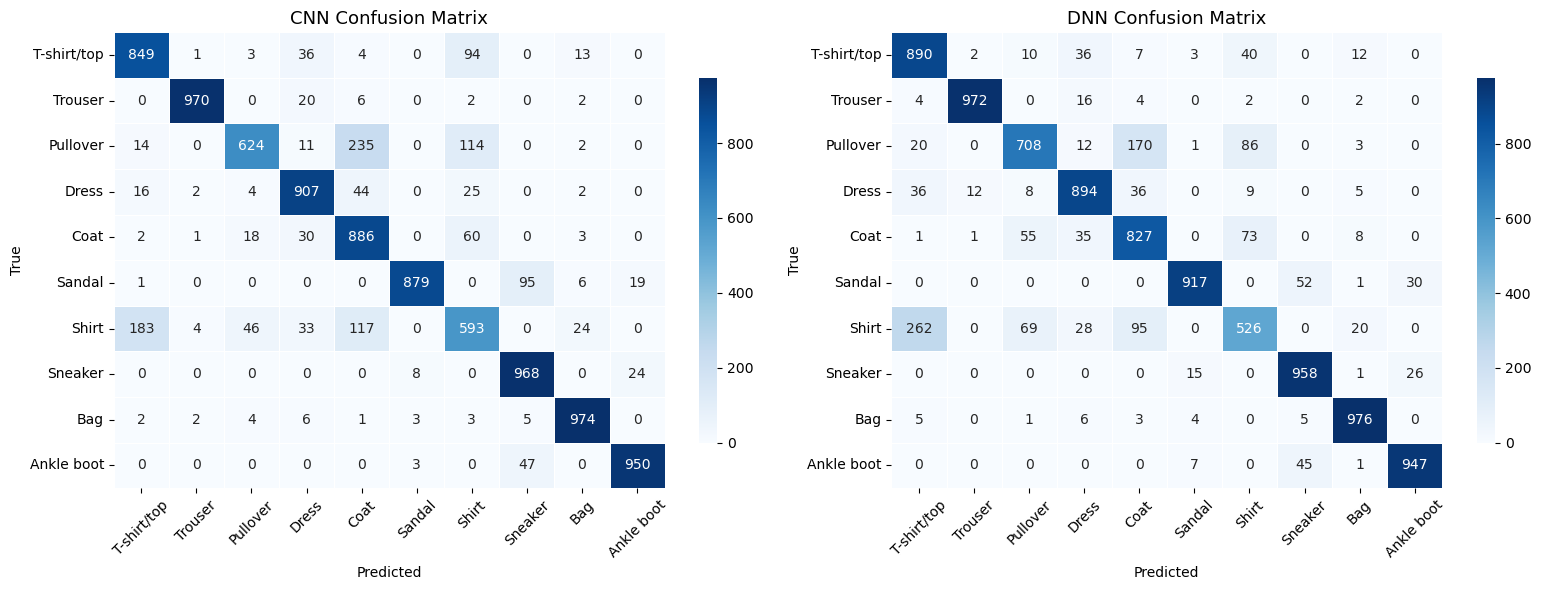

Saved: confusion_matrices.png


In [37]:
# ---- Confusion Matrices ----
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, preds, title in zip(axes, [cnn_preds, dnn_preds], ['CNN', 'DNN']):
    cm = confusion_matrix(y_true, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                linewidths=0.5, cbar_kws={'shrink': 0.8})
    ax.set_title(f'{title} Confusion Matrix', fontsize=13)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    ax.tick_params(axis='x', rotation=45)
    ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: confusion_matrices.png')

In [38]:
# ---- Classification Reports ----
print("\n" + "=" * 55)
print("  CLASSIFICATION REPORT - CNN")
print("=" * 55)
print(classification_report(y_true, cnn_preds, target_names=CLASS_NAMES, digits=4))

print("\n" + "=" * 55)
print("  CLASSIFICATION REPORT - DNN")
print("=" * 55)
print(classification_report(y_true, dnn_preds, target_names=CLASS_NAMES, digits=4))


  CLASSIFICATION REPORT - CNN
              precision    recall  f1-score   support

 T-shirt/top     0.7957    0.8490    0.8215      1000
     Trouser     0.9898    0.9700    0.9798      1000
    Pullover     0.8927    0.6240    0.7345      1000
       Dress     0.8696    0.9070    0.8879      1000
        Coat     0.6852    0.8860    0.7728      1000
      Sandal     0.9843    0.8790    0.9287      1000
       Shirt     0.6655    0.5930    0.6272      1000
     Sneaker     0.8682    0.9680    0.9154      1000
         Bag     0.9493    0.9740    0.9615      1000
  Ankle boot     0.9567    0.9500    0.9533      1000

    accuracy                         0.8600     10000
   macro avg     0.8657    0.8600    0.8583     10000
weighted avg     0.8657    0.8600    0.8583     10000


  CLASSIFICATION REPORT - DNN
              precision    recall  f1-score   support

 T-shirt/top     0.7307    0.8900    0.8025      1000
     Trouser     0.9848    0.9720    0.9784      1000
    Pullover    

In [39]:
# ===================================================================
#  Select Best Model & Export
# ===================================================================
best_model_name = 'CNN' if cnn_acc >= dnn_acc else 'DNN'
best_model = cnn_model if cnn_acc >= dnn_acc else dnn_model

print(f"Best model: {best_model_name}")
print(f"  Accuracy:  {max(cnn_acc, dnn_acc):.4f}")
print(f"  F1 Score:  {max(cnn_f1, dnn_f1):.4f}")

# Create models/ directory
Path("models").mkdir(exist_ok=True)

# Export 1: Full model (recommended)
export_path = "models/best_model.pt"
torch.save(best_model, export_path)
print(f"\n[1] Full model: {export_path}")

# Export 2: State dict (lighter, needs CNN/DNN class at load time)
state_dict_path = "models/best_model_state_dict.pt"
torch.save({
    'model_state_dict': best_model.state_dict(),
    'model_name': best_model_name,
    'accuracy': max(cnn_acc, dnn_acc),
    'f1_score': max(cnn_f1, dnn_f1),
    'classes': CLASS_NAMES,
}, state_dict_path)
print(f"[2] State dict: {state_dict_path}")

# Export 3: Metrics summary
metrics_summary = {
    'cnn': {'accuracy': cnn_acc, 'precision': cnn_p, 'recall': cnn_r, 'f1': cnn_f1, 'params': cnn_params},
    'dnn': {'accuracy': dnn_acc, 'precision': dnn_p, 'recall': dnn_r, 'f1': dnn_f1, 'params': dnn_params},
    'best_model': best_model_name,
}
with open('models/metrics_summary.json', 'w') as f:
    json.dump(metrics_summary, f, indent=2, default=float)
print(f"[3] Metrics:  models/metrics_summary.json")

Best model: DNN
  Accuracy:  0.8615
  F1 Score:  0.8586

[1] Full model: models/best_model.pt
[2] State dict: models/best_model_state_dict.pt
[3] Metrics:  models/metrics_summary.json


In [40]:
# ===================================================================
#  Verify Exported Model
# ===================================================================
print("Verifying exported model...")

loaded = torch.load(export_path, map_location='cpu', weights_only=False)
loaded.eval()

# Compare predictions on 5 samples
sample_inputs, _ = next(iter(test_loader))
sample_inputs = sample_inputs[:5]

with torch.no_grad():
    original_preds = best_model.cpu()(sample_inputs).argmax(1)
    loaded_preds = loaded(sample_inputs).argmax(1)

match = (original_preds == loaded_preds).all().item()
print(f"Predictions match: {match}")
print(f"Original : {original_preds.tolist()}")
print(f"Loaded   : {loaded_preds.tolist()}")

if match:
    print("\n[OK] Model export verified - baked into Docker image at build time.")
else:
    print("\n[FAIL] Prediction mismatch - check export.")

Verifying exported model...
Predictions match: True
Original : [9, 2, 1, 1, 6]
Loaded   : [9, 2, 1, 1, 6]

[OK] Model export verified - baked into Docker image at build time.


##  Docker Build, Run & API Test
---

 Build the Docker image with the trained model baked in (`MODEL_PATH` auto-loads on startup),
 then test predictions — all with simple command-line commands.

#### Endpoints:
+   GET  /health
+   GET  /classes
+   POST /predict-json     (JSON: {"image": [784 ints]})
+   POST /predict          (multipart image file)

In [46]:
# ---- Step 1: Build Docker image (model baked in) ----
print("=" * 50)
print("Building Docker image...")
print("=" * 50)
!docker build -t fashionmnist-server .

print("\n" + "=" * 50)
print("Starting container...")
print("=" * 50)
!docker rm -f fashionmnist-test 2>/dev/null; true
!docker run -d --name fashionmnist-test -p 8000:8000 fashionmnist-server

import time, requests, json
from pathlib import Path

PORT = 8000
BASE = f"http://localhost:{PORT}"

# ---- Wait for server (model auto-loaded from MODEL_PATH) ----
print("\nWaiting for server to be ready...")
for i in range(60):
    time.sleep(1)
    try:
        r = requests.get(f"{BASE}/health", timeout=2)
        if r.status_code == 200:
            print(f"Server ready! {r.json()}")
            break
    except requests.ConnectionError:
        if i % 10 == 9:
            print(f"  still waiting... ({i+1}s)")

# ---- Verify model is loaded via /classes ----
print("\nClasses:")
!curl -s {BASE}/classes | python3 -m json.tool

Building Docker image...
DEPRECATED: The legacy builder is deprecated and will be removed in a future release.
            Install the buildx component to build images with BuildKit:
            https://docs.docker.com/go/buildx/

Sending build context to Docker daemon  7.501MB
Step 1/17 : FROM continuumio/miniconda3:latest
 ---> a297bed7a4be
Step 2/17 : ENV PYTHONUNBUFFERED=1
 ---> Using cache
 ---> 7fb764be216b
Step 3/17 : WORKDIR /app
 ---> Using cache
 ---> 5aa976030b00
Step 4/17 : RUN apt-get update && apt-get install -y --no-install-recommends     curl libjpeg62-turbo-dev     && rm -rf /var/lib/apt/lists/*
 ---> Using cache
 ---> 482d7dfe28f3
Step 5/17 : COPY environment.yml .
 ---> Using cache
 ---> 2f0bf1d433cf
Step 6/17 : RUN conda env create -f environment.yml && conda clean -afy
 ---> Using cache
 ---> f40e9be66892
Step 7/17 : COPY server.py .
 ---> Using cache
 ---> bf9611dd4098
Step 8/17 : COPY cnn.py .
 ---> Using cache
 ---> 298a371e405b
Step 9/17 : COPY dnn.py .
 ---> U

In [ ]:
# ===================================================================
#  test /predict-json（1 image json data） 
# ===================================================================
import torchvision

raw_ds = torchvision.datasets.FashionMNIST('./data', train=False, download=True,
                                           transform=torchvision.transforms.ToTensor())
img_tensor, true_label = raw_ds[0]
pixels_2d = (img_tensor.squeeze() * 255).int().tolist()  # 28x28, 0-255

print(f"True label: {true_label} ({CLASS_NAMES[true_label]})")
print(f"Pixels shape: {len(pixels_2d)}x{len(pixels_2d[0])}, range: [{pixels_2d[0][0]}, {pixels_2d[0][-1]}]")

# ---- curl ----
payload = json.dumps({"image": [int(p) for row in pixels_2d for p in row]})  # flat 784
with open("/tmp/test_pixels.json", "w") as f:
    f.write(payload)

print("\n--- curl result ---")
!curl -s -X POST {BASE}/predict-json -H 'Content-Type: application/json' -d @/tmp/test_pixels.json | python3 -m json.tool

True label: 9 (Ankle boot)
Pixels shape: 28x28, range: [0, 0]

--- curl 结果 ---
{
    "predicted_class": "Ankle boot",
    "predicted_index": 9,
    "probabilities": {
        "T-shirt/top": 0.0,
        "Trouser": 0.0,
        "Pullover": 0.0,
        "Dress": 0.0,
        "Coat": 0.0,
        "Sandal": 0.034,
        "Shirt": 0.0,
        "Sneaker": 0.0609,
        "Bag": 0.0,
        "Ankle boot": 0.905
    }
}


In [ ]:
# ===================================================================
#  test /predict-json （5 images json data） 
# ===================================================================
N = 5
images = []
for i in range(N):
    img_t, label = raw_ds[i]
    flat = [int(p) for row in (img_t.squeeze() * 255).int().tolist() for p in row]
    images.append(flat)
    print(f"  [{i}] true={CLASS_NAMES[label]}")

with open("/tmp/test_batch.json", "w") as f:
    json.dump({"images": images}, f)

print(f"\n--- curl ---")
!curl -s -X POST {BASE}/predict-json -H 'Content-Type: application/json' -d @/tmp/test_batch.json | python3 -m json.tool

  [0] true=Ankle boot
  [1] true=Pullover
  [2] true=Trouser
  [3] true=Trouser
  [4] true=Shirt

--- curl ---
{
    "predictions": [
        {
            "index": 0,
            "predicted_class": "Ankle boot",
            "predicted_index": 9
        },
        {
            "index": 1,
            "predicted_class": "Pullover",
            "predicted_index": 2
        },
        {
            "index": 2,
            "predicted_class": "Trouser",
            "predicted_index": 1
        },
        {
            "index": 3,
            "predicted_class": "Trouser",
            "predicted_index": 1
        },
        {
            "index": 4,
            "predicted_class": "Shirt",
            "predicted_index": 6
        }
    ]
}


In [49]:
# ---- Stop and remove Docker container ----
!docker stop fashionmnist-test
!docker rm fashionmnist-test
print("Container stopped and removed")

fashionmnist-test
fashionmnist-test
Container stopped and removed
